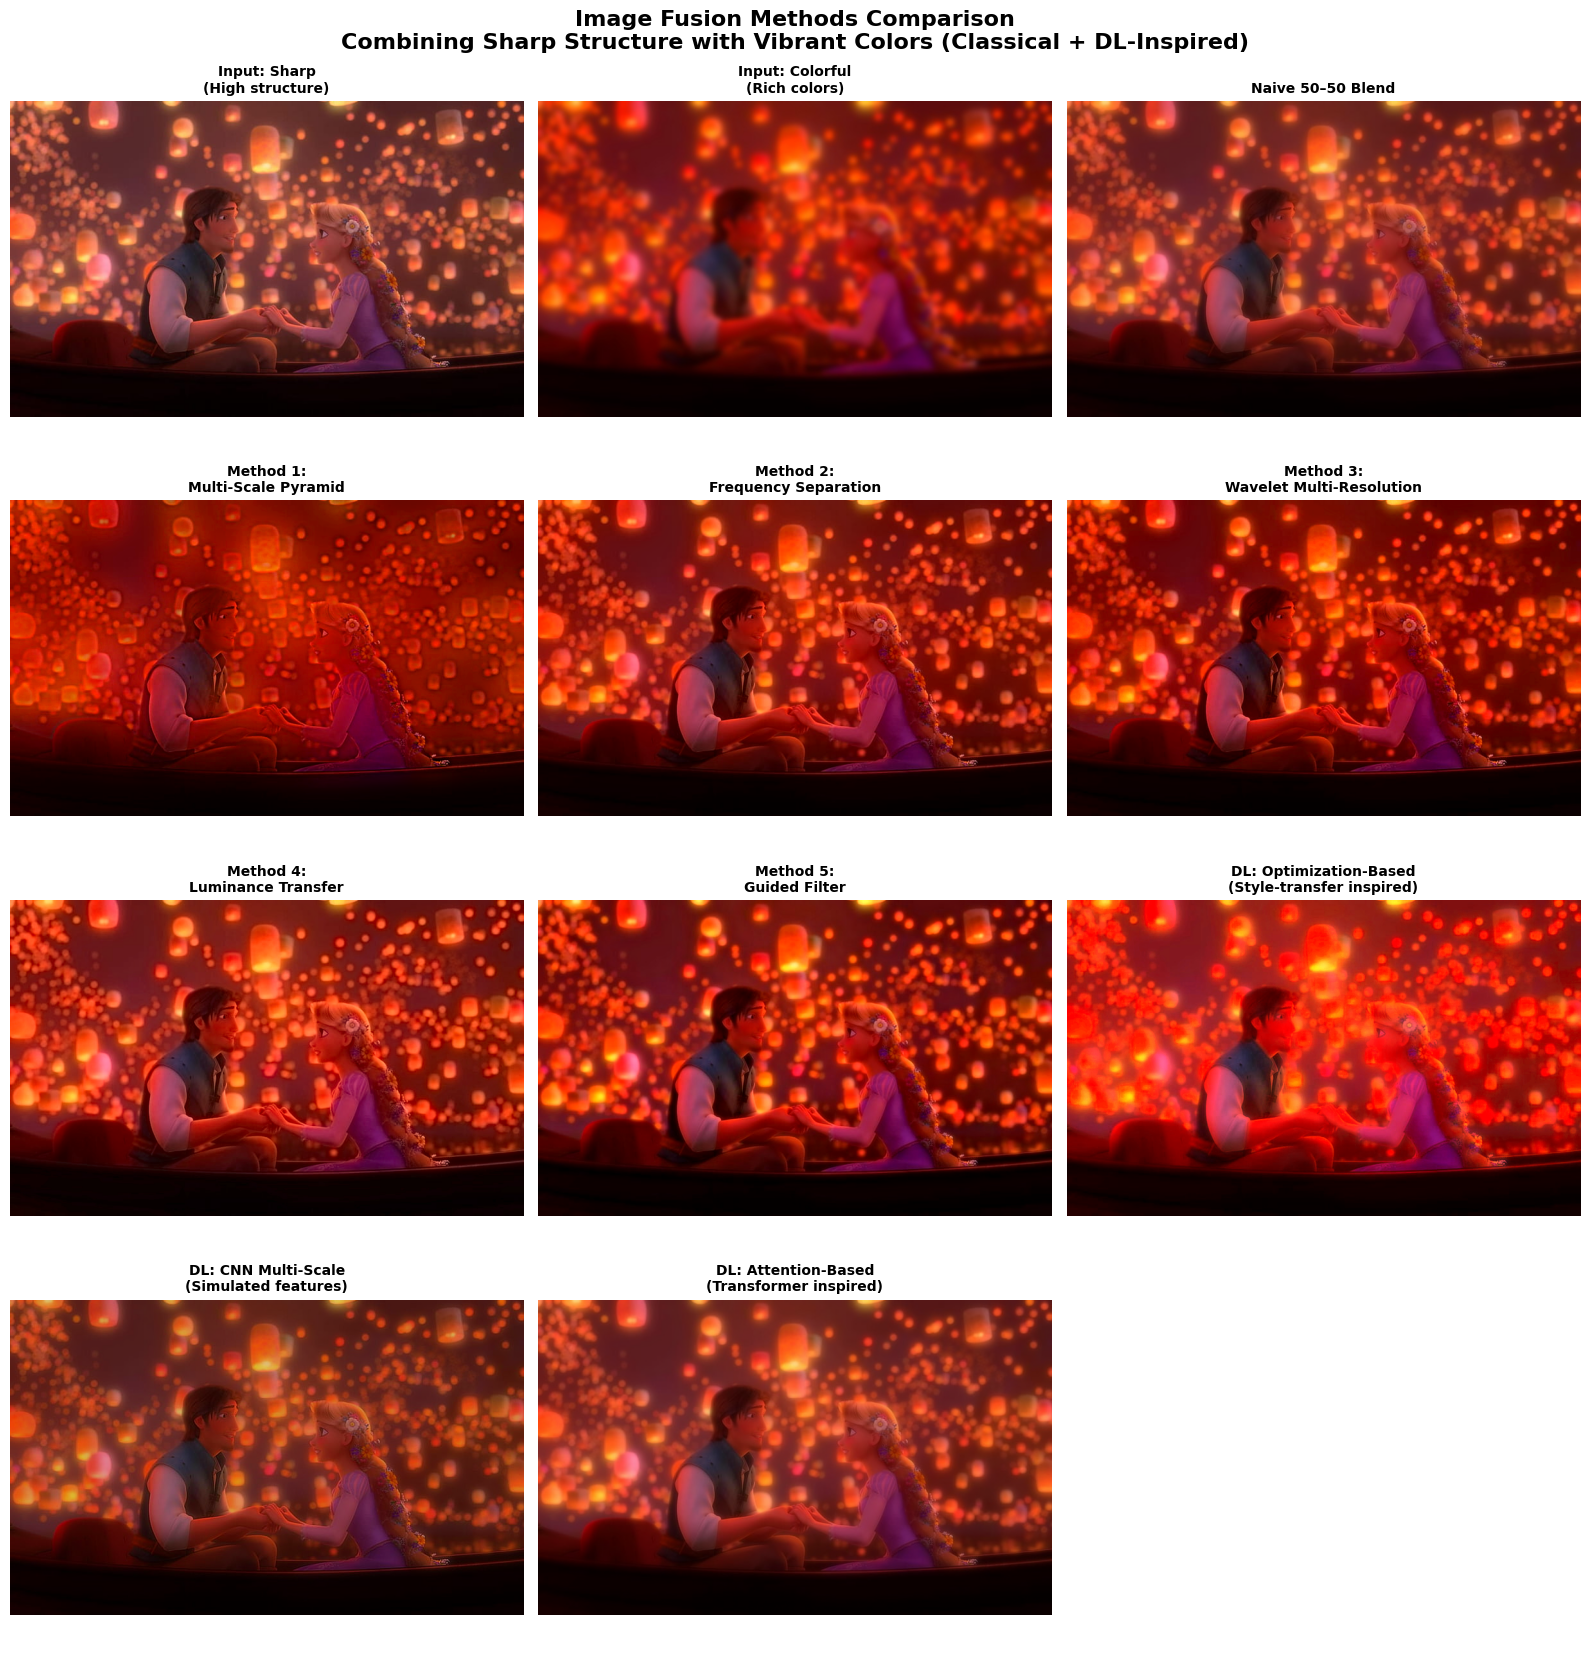

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, laplace
from scipy.optimize import minimize
from typing import Dict


class ImprovedFusionPipeline:
    def __init__(self, sharp_path: str, colorful_path: str):
        self.img_sharp = cv2.imread(sharp_path)
        self.img_color = cv2.imread(colorful_path)

        if self.img_sharp is None or self.img_color is None:
            raise ValueError("Could not read one or both images")

        if self.img_sharp.shape != self.img_color.shape:
            h = min(self.img_sharp.shape[0], self.img_color.shape[0])
            w = min(self.img_sharp.shape[1], self.img_color.shape[1])
            self.img_sharp = cv2.resize(self.img_sharp, (w, h))
            self.img_color = cv2.resize(self.img_color, (w, h))

        self.img_sharp_bgr = self.img_sharp
        self.img_color_bgr = self.img_color

        self.img_sharp_rgb = cv2.cvtColor(self.img_sharp, cv2.COLOR_BGR2RGB)
        self.img_color_rgb = cv2.cvtColor(self.img_color, cv2.COLOR_BGR2RGB)

        self.img_sharp_rgb_f = self.img_sharp_rgb.astype(np.float32) / 255.0
        self.img_color_rgb_f = self.img_color_rgb.astype(np.float32) / 255.0

        self.result = None
        self.pyramid_result = None
        self.wavelet_result = None

    def method1_multiscale_decomposition(self) -> np.ndarray:
        sharp = self.img_sharp_rgb.astype(np.float32) / 255.0
        colorful = self.img_color_rgb.astype(np.float32) / 255.0

        low_freq = cv2.GaussianBlur(colorful, (0, 0), sigmaX=20)
        high_freq = sharp - cv2.GaussianBlur(sharp, (0, 0), sigmaX=5)

        result = np.clip(low_freq + high_freq * 1.2, 0, 1)

        result_hsv = cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        result_hsv[:, :, 1] = np.clip(result_hsv[:, :, 1] * 1.15, 0, 255)
        result = cv2.cvtColor(result_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        self.pyramid_result = result
        return result

    def method2_frequency_separation(self) -> np.ndarray:
        sharp = self.img_sharp_rgb.astype(np.float32)
        colorful = self.img_color_rgb.astype(np.float32)

        radius = 15
        sharp_low = cv2.GaussianBlur(sharp, (0, 0), sigmaX=radius)
        colorful_low = cv2.GaussianBlur(colorful, (0, 0), sigmaX=radius)
        sharp_high = sharp - sharp_low

        result = colorful_low + sharp_high
        result = np.clip(result, 0, 255).astype(np.uint8)

        self.result = result
        return result

    def method3_wavelet_fusion(self) -> np.ndarray:
        sharp = self.img_sharp_rgb.astype(np.float32)
        colorful = self.img_color_rgb.astype(np.float32)

        result = np.zeros_like(sharp)

        for c in range(3):
            scales = [2, 5, 10, 20]
            base = gaussian_filter(colorful[:, :, c], sigma=scales[-1])

            details = []
            prev = sharp[:, :, c]
            for sigma in scales:
                blurred = gaussian_filter(sharp[:, :, c], sigma=sigma)
                detail = prev - blurred
                details.append(detail)
                prev = blurred

            reconstruction = base
            for detail in reversed(details):
                reconstruction += detail * 1.1

            result[:, :, c] = reconstruction

        result = np.clip(result, 0, 255).astype(np.uint8)

        result_hsv = cv2.cvtColor(result, cv2.COLOR_RGB2HSV).astype(np.float32)
        result_hsv[:, :, 1] = np.clip(result_hsv[:, :, 1] * 1.1, 0, 255)
        result = cv2.cvtColor(result_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        self.wavelet_result = result
        return result

    def method4_luminance_transfer(self) -> np.ndarray:
        sharp_lab = cv2.cvtColor(self.img_sharp_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        colorful_lab = cv2.cvtColor(self.img_color_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

        sharp_luminance = sharp_lab[:, :, 0]

        result_lab = colorful_lab.copy()
        result_lab[:, :, 0] = sharp_luminance

        result = cv2.cvtColor(result_lab.astype(np.uint8), cv2.COLOR_LAB2RGB)
        return result

    def method5_guided_filter_fusion(self) -> np.ndarray:
        sharp = self.img_sharp_rgb.astype(np.float32)
        colorful = self.img_color_rgb.astype(np.float32)

        result = np.zeros_like(colorful)

        for c in range(3):
            sharp_base = cv2.GaussianBlur(sharp[:, :, c], (0, 0), sigmaX=10)
            sharp_details = sharp[:, :, c] - sharp_base
            result[:, :, c] = colorful[:, :, c] + sharp_details * 0.8

        result = np.clip(result, 0, 255).astype(np.uint8)
        return result

    def extract_edge_features(self, img: np.ndarray) -> Dict[str, np.ndarray]:
        features = {}
        imgf = img.copy()
        if imgf.dtype != np.float32 and imgf.dtype != np.float64:
            imgf = imgf.astype(np.float32) / 255.0

        for scale in [1, 2, 4]:
            blurred = gaussian_filter(imgf, sigma=scale)
            if blurred.ndim == 3:
                gray = cv2.cvtColor((blurred * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            else:
                gray = (blurred * 255).astype(np.uint8)
            sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
            sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
            magnitude = np.sqrt(sobelx**2 + sobely**2)
            features[f'edge_scale_{scale}'] = magnitude

        if imgf.ndim == 3:
            grayf = cv2.cvtColor((imgf * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)
        else:
            grayf = (imgf * 255).astype(np.float32)
        features['laplacian'] = laplace(grayf)

        return features

    def extract_color_stats(self, img: np.ndarray) -> dict:
        stats = {}
        if img.dtype == np.float32 or img.dtype == np.float64:
            imgf = np.clip(img, 0, 1)
            img_u8 = (imgf * 255).astype(np.uint8)
        else:
            img_u8 = img.astype(np.uint8)
            imgf = img_u8.astype(np.float32) / 255.0

        for c in range(3):
            stats[f'mean_c{c}'] = np.mean(imgf[:, :, c])
            stats[f'std_c{c}'] = np.std(imgf[:, :, c])

        img_hsv = cv2.cvtColor(img_u8, cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
        stats['mean_hue'] = np.mean(img_hsv[:, :, 0])
        stats['mean_sat'] = np.mean(img_hsv[:, :, 1])
        stats['mean_val'] = np.mean(img_hsv[:, :, 2])

        return stats

    def compute_structure_loss(self, result: np.ndarray, target_edges: dict) -> float:
        result_edges = self.extract_edge_features(result)
        loss = 0.0
        for key in target_edges:
            diff = result_edges[key] - target_edges[key]
            loss += np.sum(diff ** 2)
        return loss / result.size

    def compute_color_loss(self, result: np.ndarray, target_stats: dict) -> float:
        result_stats = self.extract_color_stats(result)
        loss = 0.0
        for key in target_stats:
            diff = result_stats[key] - target_stats[key]
            loss += diff ** 2
        return loss

    def fusion_method_optimization(self, iterations: int = 3) -> np.ndarray:
        sharp_f = self.img_sharp_rgb_f.copy()
        color_f = self.img_color_rgb_f.copy()

        sharp_edges = self.extract_edge_features(sharp_f)
        color_stats = self.extract_color_stats(color_f)

        result = color_f.copy()

        for iteration in range(iterations):
            sharp_details = sharp_f - gaussian_filter(sharp_f, sigma=3)
            alpha = 0.5 - (iteration * 0.1)
            result = result + sharp_details * alpha
            result_hsv = cv2.cvtColor((np.clip(result, 0, 1) * 255).astype(np.uint8),
                                      cv2.COLOR_RGB2HSV).astype(np.float32)
            target_hsv = cv2.cvtColor((color_f * 255).astype(np.uint8),
                                      cv2.COLOR_RGB2HSV).astype(np.float32)
            result_hsv[:, :, 1] = target_hsv[:, :, 1]
            result = cv2.cvtColor(result_hsv.astype(np.uint8),
                                  cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
            result = np.clip(result, 0, 1)

        result_u8 = (result * 255).astype(np.uint8)
        cv2.imwrite('dl_fusion_optimization.png', cv2.cvtColor(result_u8, cv2.COLOR_RGB2BGR))
        return result_u8

    def fusion_method_cnn_inspired(self) -> np.ndarray:
        sharp = self.img_sharp_rgb_f
        colorful = self.img_color_rgb_f

        scales = [1, 2, 4, 8, 16]

        sharp_features = []
        colorful_features = []
        for scale in scales:
            sharp_feat = gaussian_filter(sharp, sigma=scale)
            colorful_feat = gaussian_filter(colorful, sigma=scale)
            sharp_features.append(sharp_feat)
            colorful_features.append(colorful_feat)

        result = np.zeros_like(sharp)
        for i, scale in enumerate(scales):
            weight_sharp = np.exp(-scale / 4)
            weight_color = 1 - weight_sharp
            if i == 0:
                detail_sharp = sharp - sharp_features[0]
                result += detail_sharp
            else:
                detail_sharp = sharp_features[i - 1] - sharp_features[i]
                detail_color = colorful_features[i - 1] - colorful_features[i]
                result += detail_sharp * weight_sharp + detail_color * weight_color
        result += colorful_features[-1]

        result_u8 = np.clip(result * 255, 0, 255).astype(np.uint8)
        cv2.imwrite('dl_fusion_cnn.png', cv2.cvtColor(result_u8, cv2.COLOR_RGB2BGR))
        return result_u8

    def fusion_method_attention(self) -> np.ndarray:
        sharp = self.img_sharp_rgb_f
        colorful = self.img_color_rgb_f

        gray_sharp = cv2.cvtColor((sharp * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        edges_sharp = cv2.Canny(gray_sharp, 50, 150)

        dist = cv2.distanceTransform(255 - edges_sharp, cv2.DIST_L2, 5)
        attention_sharp = 1 - (dist / (dist.max() + 1e-8))
        attention_sharp = gaussian_filter(attention_sharp, sigma=10)

        hsv_color = cv2.cvtColor((colorful * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
        attention_color = hsv_color[:, :, 1].astype(np.float32) / 255.0
        attention_color = gaussian_filter(attention_color, sigma=10)

        attention_sharp = attention_sharp / (attention_sharp.max() + 1e-8)
        attention_color = attention_color / (attention_color.max() + 1e-8)

        total_attention = attention_sharp + attention_color + 1e-8
        weight_sharp = attention_sharp / total_attention
        weight_color = attention_color / total_attention

        result = np.zeros_like(sharp)
        for c in range(3):
            result[:, :, c] = (sharp[:, :, c] * weight_sharp +
                               colorful[:, :, c] * weight_color)

        result_u8 = np.clip(result * 255, 0, 255).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(attention_sharp, cmap='hot')
        axes[0].axis('off')

        axes[1].imshow(attention_color, cmap='hot')
        axes[1].axis('off')

        axes[2].imshow(result_u8)
        axes[2].axis('off')

        plt.tight_layout()
        plt.savefig('dl_attention_maps.png', dpi=150)
        plt.close()

        cv2.imwrite('dl_fusion_attention.png', cv2.cvtColor(result_u8, cv2.COLOR_RGB2BGR))
        return result_u8

    def compare_all_methods(self):
        pyramid = self.method1_multiscale_decomposition()
        frequency = self.method2_frequency_separation()
        wavelet = self.method3_wavelet_fusion()
        luminance = self.method4_luminance_transfer()
        guided = self.method5_guided_filter_fusion()

        opt_dl = self.fusion_method_optimization(iterations=3)
        cnn_dl = self.fusion_method_cnn_inspired()
        attn_dl = self.fusion_method_attention()

        sharp = self.img_sharp_rgb
        colorful = self.img_color_rgb
        naive = (sharp.astype(np.float32) * 0.5 +
                 colorful.astype(np.float32) * 0.5).astype(np.uint8)

        fig, axes = plt.subplots(4, 3, figsize=(16, 18))
        fig.suptitle(
            'Image Fusion Methods Comparison\n'
            'Combining Sharp Structure with Vibrant Colors (Classical + DL-Inspired)',
            fontsize=16, fontweight='bold', y=0.93
        )

        panels = [
            ("Input: Sharp\n(High structure)", sharp),
            ("Input: Colorful\n(Rich colors)", colorful),
            ("Naive 50–50 Blend", naive),

            ("Method 1:\nMulti-Scale Pyramid", pyramid),
            ("Method 2:\nFrequency Separation", frequency),
            ("Method 3:\nWavelet Multi-Resolution", wavelet),

            ("Method 4:\nLuminance Transfer", luminance),
            ("Method 5:\nGuided Filter", guided),
            ("DL: Optimization-Based\n(Style-transfer inspired)", opt_dl),

            ("DL: CNN Multi-Scale\n(Simulated features)", cnn_dl),
            ("DL: Attention-Based\n(Transformer inspired)", attn_dl),
        ]

        for idx, (title, img) in enumerate(panels):
            r = idx // 3
            c = idx % 3
            ax = axes[r, c]
            ax.imshow(img)
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.axis('off')

        axes[3, 2].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig('all_fusion_methods_comparison.png', dpi=200, bbox_inches='tight')

        classical_methods = [
            (pyramid, "fusion_method_1.png"),
            (frequency, "fusion_method_2.png"),
            (wavelet, "fusion_method_3.png"),
            (luminance, "fusion_method_4.png"),
            (guided, "fusion_method_5.png"),
        ]
        for img, name in classical_methods:
            cv2.imwrite(name, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        dl_methods = [
            (opt_dl, "dl_fusion_optimization.png"),
            (cnn_dl, "dl_fusion_cnn.png"),
            (attn_dl, "dl_fusion_attention.png"),
        ]
        for img, name in dl_methods:
            cv2.imwrite(name, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        return {
            'pyramid': pyramid,
            'frequency': frequency,
            'wavelet': wavelet,
            'luminance': luminance,
            'guided': guided,
            'dl_optimization': opt_dl,
            'dl_cnn': cnn_dl,
            'dl_attention': attn_dl
        }


if __name__ == "__main__":
    sharp_img = "tangled2.jpeg"
    colorful_img = "tangled1.jpeg"

    try:
        pipeline = ImprovedFusionPipeline(sharp_img, colorful_img)
        results = pipeline.compare_all_methods()
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
